In [ ]:

df = pd.read_csv('/content/seasonal_agriculture_performance_dataset (1).csv')

# 2. Inspect missing values
print("Missing values before imputation:")
print(df[['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']].isnull().sum())

# 3. Impute missing values using seasonal & crop-wise medians
df['Rainfall_mm'] = df.groupby(['Season', 'Crop'])['Rainfall_mm'].transform(
    lambda x: x.fillna(x.median())
)
df['Soil_Moisture_pct'] = df.groupby(['Season', 'Crop'])['Soil_Moisture_pct'].transform(
    lambda x: x.fillna(x.median())
)
df['Yield_Tonnes_Ha'] = df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].transform(
    lambda x: x.fillna(x.median())
)

print("Preprocessing Complete: Zero missing values remaining.")




Missing values before imputation:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64
Preprocessing Complete: Zero missing values remaining.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Handle missing values using median imputation
df_clean = df.copy()
df_clean['Rainfall_mm'] = df_clean.groupby(['Season', 'Crop'])['Rainfall_mm'].transform(lambda x: x.fillna(x.median()))
df_clean['Soil_Moisture_pct'] = df_clean.groupby(['Season', 'Crop'])['Soil_Moisture_pct'].transform(lambda x: x.fillna(x.median()))
df_clean['Yield_Tonnes_Ha'] = df_clean.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].transform(lambda x: x.fillna(x.median()))

# 2. Feature Selection and Encoding
features = ['Season', 'Crop', 'Irrigation_Method', 'Rainfall_mm',
            'Avg_Temperature_C', 'Humidity_pct', 'Soil_pH',
            'Soil_Moisture_pct', 'Fertilizer_kg_ha', 'Seed_Quality_Score']

X = pd.get_dummies(df_clean[features], drop_first=True)
y = df_clean['Yield_Tonnes_Ha']

# 3. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Model Training
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Evaluation
y_pred = rf_model.predict(X_test)
print(f"Model R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, y_pred):.4f} t/ha")


Model R² Score: 0.9688
Mean Absolute Error: 0.7404 t/ha


/tmp/ipykernel_1328/3549343774.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='viridis', ci=None)
/tmp/ipykernel_1328/3549343774.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='viridis', ci=None)
/tmp/ipykernel_1328/3549343774.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', palette='Set2')


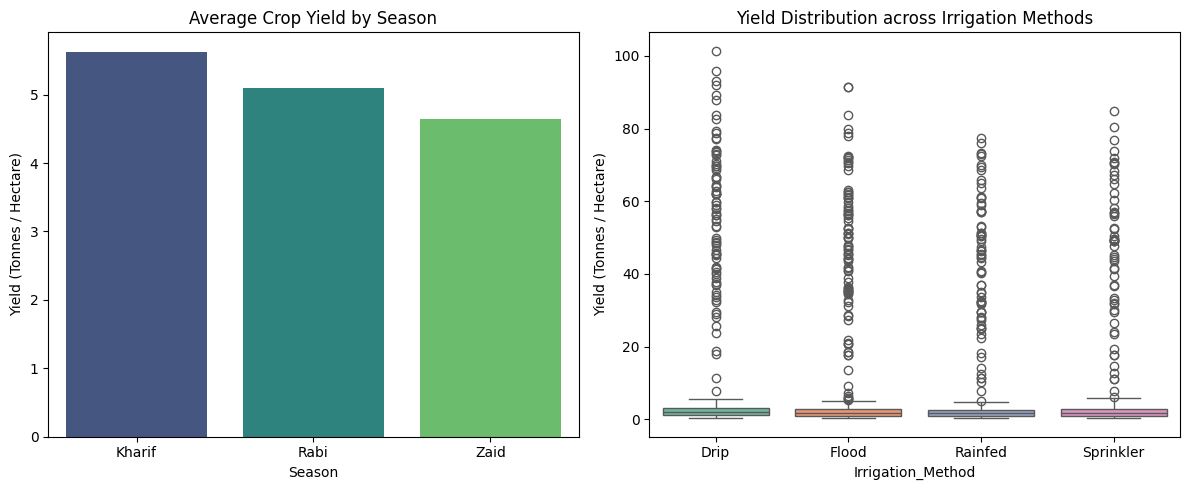

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Plot 1: Seasonal Yield Comparison
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha', palette='viridis', ci=None)
plt.title('Average Crop Yield by Season')
plt.ylabel('Yield (Tonnes / Hectare)')

# Plot 2: Yield by Irrigation Method
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', palette='Set2')
plt.title('Yield Distribution across Irrigation Methods')
plt.ylabel('Yield (Tonnes / Hectare)')

plt.tight_layout()
plt.show()


In [27]:
import pandas as pd


df = pd.read_csv('seasonal_agriculture_performance_dataset (1).csv')

# Handle missing values using seasonal median imputation
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))

# Calculate Return on Investment (ROI %)
df['ROI_pct'] = (df['Profit_INR'] / df['Total_Cost_INR']) * 100

# Aggregating Seasonal KPIs
seasonal_summary = df.groupby('Season').agg(
    Farm_Count=('Farm_ID', 'count'),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean'),
    Total_Production_t=('Production_Tonnes', 'sum'),
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Temp_C=('Avg_Temperature_C', 'mean'),
    Avg_Revenue_INR=('Revenue_INR', 'mean'),
    Avg_Cost_INR=('Total_Cost_INR', 'mean'),
    Avg_Profit_INR=('Profit_INR', 'mean'),
    Avg_ROI_pct=('ROI_pct', 'mean'),
    Avg_Water_Eff_t_1000m3=('Water_Efficiency_t_per_1000m3', 'mean'),

).reset_index()

# Formatting for presentation output
print("=== SEASONAL MACRO-PERFORMANCE METRICS ===")
print(seasonal_summary.to_string(index=False))


=== SEASONAL MACRO-PERFORMANCE METRICS ===
Season  Farm_Count  Avg_Yield_t_ha  Total_Production_t  Avg_Rainfall_mm  Avg_Temp_C  Avg_Revenue_INR  Avg_Cost_INR  Avg_Profit_INR  Avg_ROI_pct  Avg_Water_Eff_t_1000m3
Kharif        1779        5.630616            82387.61       852.103626   28.454019    710719.055649 531804.408094   178914.647555    35.450472                5.891834
  Rabi        1627        5.094917            67498.88       435.948156   23.489183    601526.048556 513836.578365    87689.470191    17.597725                5.186122
  Zaid         594        4.637340            23098.35       299.162795   31.042088    519171.904040 543976.728956   -24804.824916    -2.467137                4.413239


In [ ]:
import pandas as pd

df = pd.read_csv('seasonal_agriculture_performance_dataset (1).csv')

# 1. Yield by Crop and Season (Tonnes/Hectare)
crop_yield_matrix = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Yield_Tonnes_Ha',
    aggfunc='mean'
).round(2)

# 2. Profitability by Crop and Season (₹)
crop_profit_matrix = df.pivot_table(
    index='Crop',
    columns='Season',
    values='Profit_INR',
    aggfunc='mean'
).round(0)

print("=== AVERAGE YIELD (TONNES/HA) BY CROP & SEASON ===")
print(crop_yield_matrix)

print("\n=== AVERAGE PROFIT (₹) BY CROP & SEASON ===")
print(crop_profit_matrix)


=== AVERAGE YIELD (TONNES/HA) BY CROP & SEASON ===
Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.46   1.18
Cotton       1.37   1.19   0.95
Groundnut    1.48   1.22   1.04
Maize        2.97   2.61   2.30
Pulses       1.04   0.87   0.65
Rice         2.71   2.33   1.90
Sugarcane   53.46  43.94  38.42
Wheat        2.26   2.06   1.75

=== AVERAGE PROFIT (₹) BY CROP & SEASON ===
Season        Kharif      Rabi      Zaid
Crop                                    
Chilli      954380.0  638572.0  448659.0
Cotton      217000.0  107344.0  -53925.0
Groundnut   108265.0   10417.0  -68872.0
Maize       -39333.0  -89133.0 -194049.0
Pulses       43339.0  -14309.0 -139228.0
Rice        -64903.0  -98428.0 -227239.0
Sugarcane  1000791.0  731613.0  583636.0
Wheat      -105872.0 -119955.0 -193209.0


In [28]:
import pandas as pd

df = pd.read_csv('seasonal_agriculture_performance_dataset (1).csv')

# Impute missing environmental values
df['Rainfall_mm'] = df['Rainfall_mm'].fillna(df['Rainfall_mm'].median())
df['Soil_Moisture_pct'] = df['Soil_Moisture_pct'].fillna(df['Soil_Moisture_pct'].median())

# Environmental conditions vs Yield per season
climate_impact = df.groupby('Season').agg(
    Avg_Rainfall_mm=('Rainfall_mm', 'mean'),
    Avg_Humidity_pct=('Humidity_pct', 'mean'),
    Avg_Soil_Moisture_pct=('Soil_Moisture_pct', 'mean'),
    Avg_Temperature_C=('Avg_Temperature_C', 'mean'),
    Yield_Per_mm_Rain=('Yield_Tonnes_Ha', lambda x: (x.mean() / df.loc[x.index, 'Rainfall_mm'].mean())),
    Avg_Yield_t_ha=('Yield_Tonnes_Ha', 'mean')
).reset_index()

print("=== ENVIRONMENTAL FACTORS VS SEASONAL YIELD ===")
print(climate_impact.to_string(index=False))


=== ENVIRONMENTAL FACTORS VS SEASONAL YIELD ===
Season  Avg_Rainfall_mm  Avg_Humidity_pct  Avg_Soil_Moisture_pct  Avg_Temperature_C  Yield_Per_mm_Rain  Avg_Yield_t_ha
Kharif       849.199663         71.812591              31.149859          28.454019           0.006646        5.643973
  Rabi       437.615366         57.893178              24.069392          23.489183           0.011610        5.080498
  Zaid       304.654714         52.012121              19.279630          31.042088           0.015316        4.665942


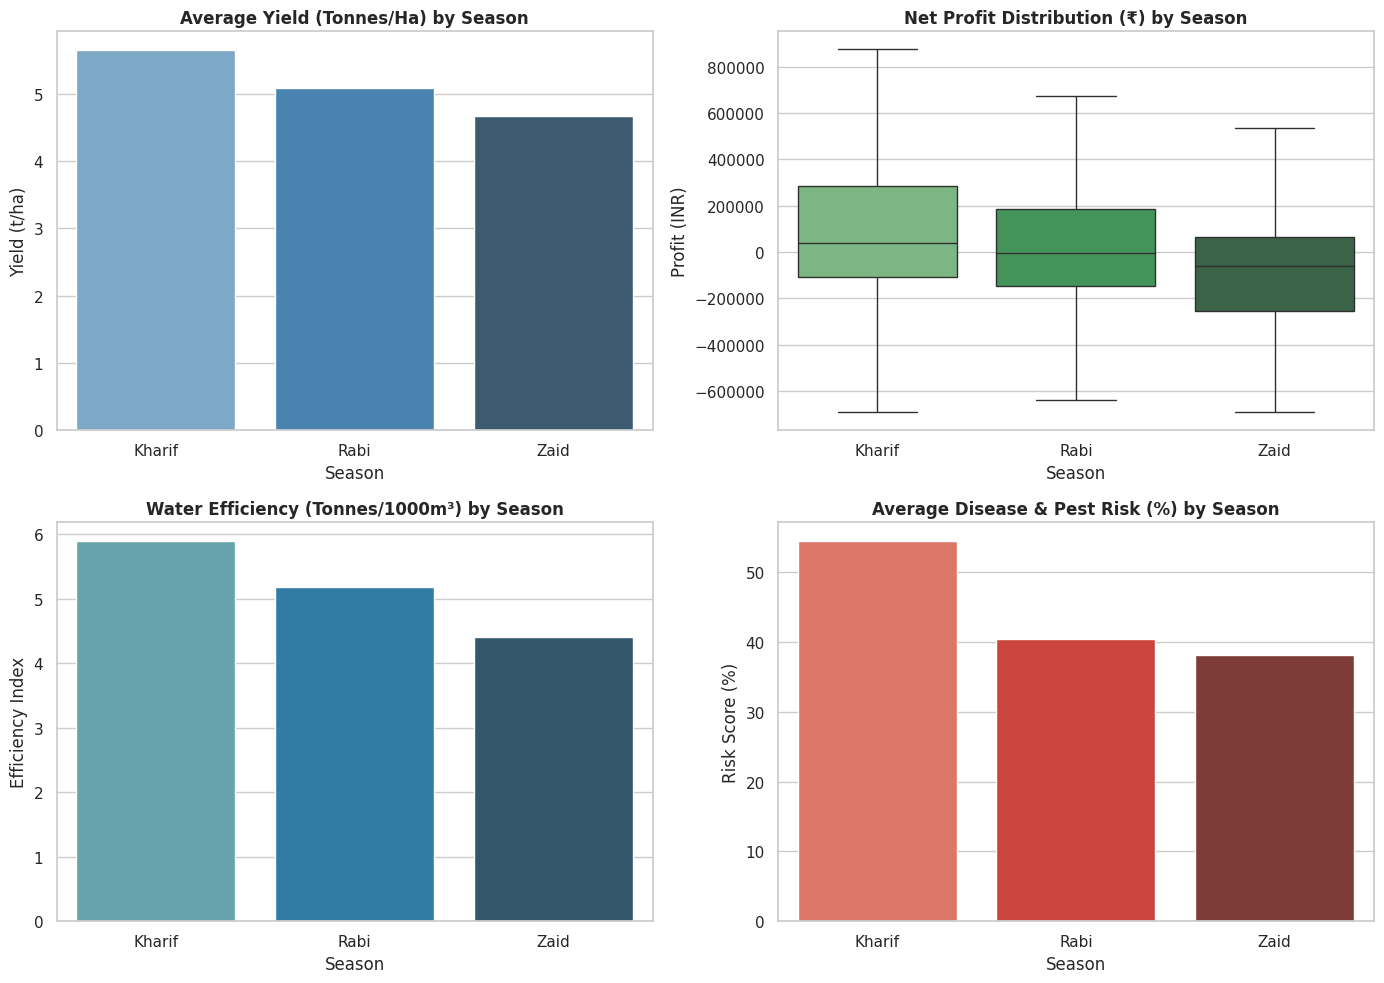

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data and prepare metrics
df = pd.read_csv('seasonal_agriculture_performance_dataset (1).csv')
df['ROI_pct'] = (df['Profit_INR'] / df['Total_Cost_INR']) * 100

# Set Seaborn theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Seasonal Yield Comparison
sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    hue='Season',
    palette='Blues_d',
    errorbar=None,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Average Yield (Tonnes/Ha) by Season', fontweight='bold')
axes[0, 0].set_ylabel('Yield (t/ha)')

# Panel 2: Seasonal Net Profit Distribution
sns.boxplot(
    data=df,
    x='Season',
    y='Profit_INR',
    hue='Season',
    palette='Greens_d',
    showfliers=False,
    ax=axes[0, 1]
)
axes[0, 1].set_title('Net Profit Distribution (₹) by Season', fontweight='bold')
axes[0, 1].set_ylabel('Profit (INR)')

# Panel 3: Water Efficiency per Season
sns.barplot(
    data=df,
    x='Season',
    y='Water_Efficiency_t_per_1000m3',
    hue='Season',
    palette='YlGnBu_d',
    errorbar=None,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Water Efficiency (Tonnes/1000m³) by Season', fontweight='bold')
axes[1, 0].set_ylabel('Efficiency Index')

# Panel 4: Disease & Pest Risk Percentage
sns.barplot(
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct',
    hue='Season',
    palette='Reds_d',
    errorbar=None,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Average Disease & Pest Risk (%) by Season', fontweight='bold')
axes[1, 1].set_ylabel('Risk Score (%)')

plt.tight_layout()
plt.savefig('seasonal_insights_dashboard_clean.png', dpi=300)
plt.show()


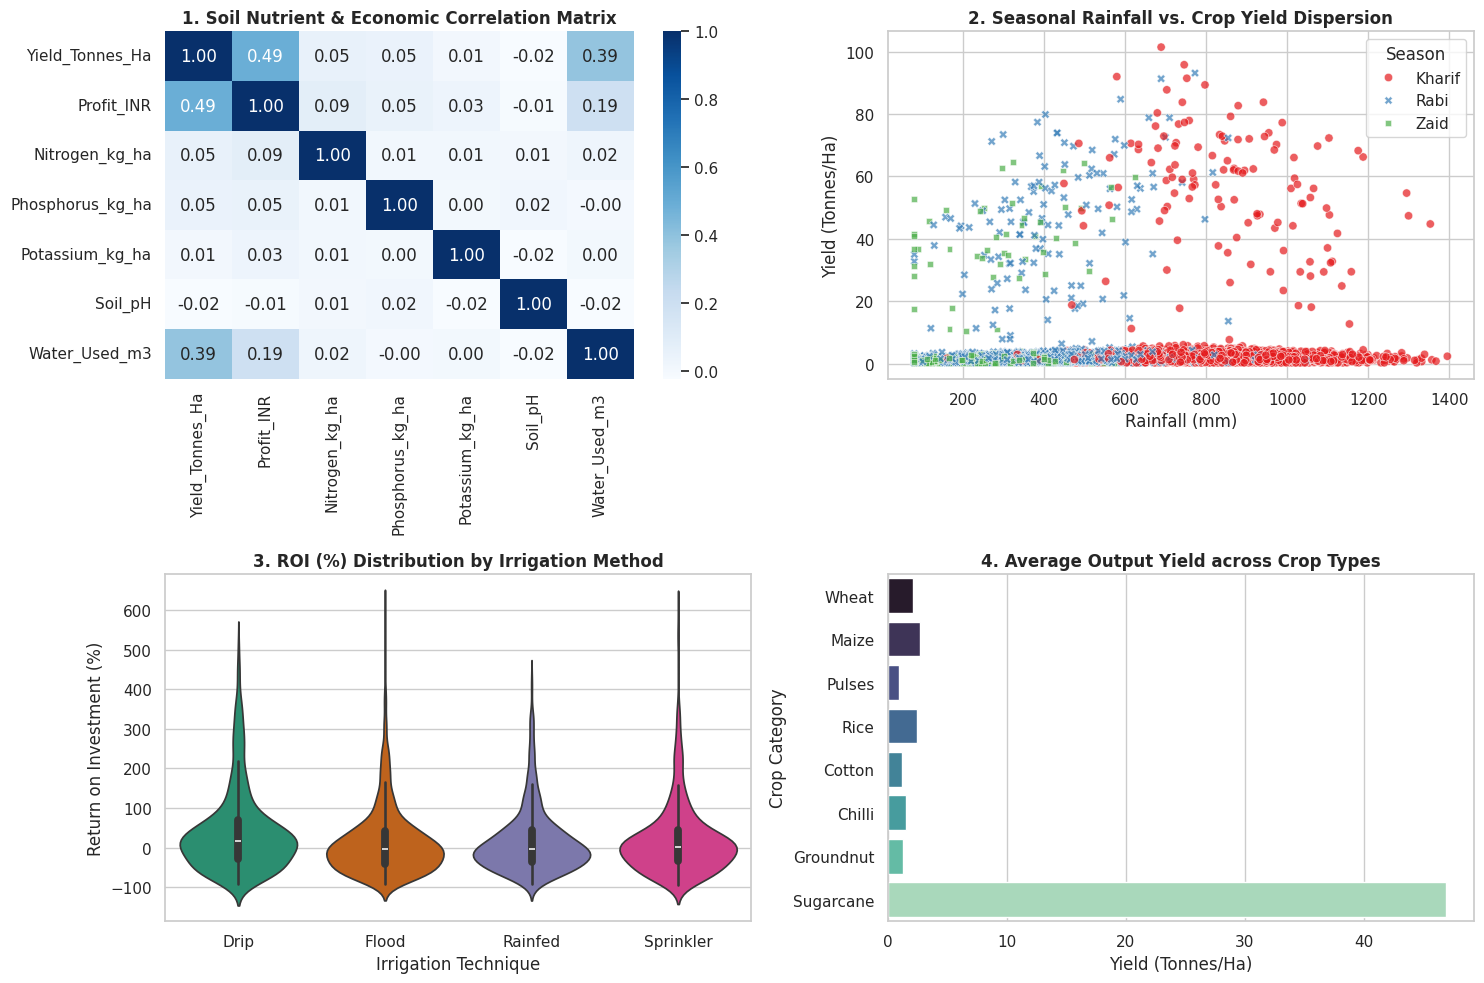

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('seasonal_agriculture_performance_dataset (1).csv')

# Data preprocessing & median imputation for missing values
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))

# Calculate ROI Percentage
df['ROI_pct'] = (df['Profit_INR'] / df['Total_Cost_INR']) * 100

# Set Seaborn theme
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# -------------------------------------------------------------------------
# Panel 1: Soil Nutrient & Economic Correlation Matrix
# -------------------------------------------------------------------------
corr_cols = ['Yield_Tonnes_Ha', 'Profit_INR', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Soil_pH', 'Water_Used_m3']
corr_matrix = df[corr_cols].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='Blues',
    ax=axes[0, 0],
    cbar=True
)
axes[0, 0].set_title('1. Soil Nutrient & Economic Correlation Matrix', fontweight='bold')

# -------------------------------------------------------------------------
# Panel 2: Seasonal Rainfall vs. Crop Yield Scatter
# -------------------------------------------------------------------------
sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season',
    style='Season',
    palette='Set1',
    alpha=0.7,
    ax=axes[0, 1]
)
axes[0, 1].set_title('2. Seasonal Rainfall vs. Crop Yield Dispersion', fontweight='bold')
axes[0, 1].set_xlabel('Rainfall (mm)')
axes[0, 1].set_ylabel('Yield (Tonnes/Ha)')

# -------------------------------------------------------------------------
# Panel 3: ROI Distribution by Irrigation Technique
# -------------------------------------------------------------------------
sns.violinplot(
    data=df,
    x='Irrigation_Method',
    y='ROI_pct',
    hue='Irrigation_Method',
    palette='Dark2',
    ax=axes[1, 0]
)
axes[1, 0].set_title('3. ROI (%) Distribution by Irrigation Method', fontweight='bold')
axes[1, 0].set_xlabel('Irrigation Technique')
axes[1, 0].set_ylabel('Return on Investment (%)')

# -------------------------------------------------------------------------
# Panel 4: Average Output Yield by Crop Type
# -------------------------------------------------------------------------
sns.barplot(
    data=df,
    y='Crop',
    x='Yield_Tonnes_Ha',
    hue='Crop',
    palette='mako',
    errorbar=None,
    ax=axes[1, 1]
)
axes[1, 1].set_title('4. Average Output Yield across Crop Types', fontweight='bold')
axes[1, 1].set_xlabel('Yield (Tonnes/Ha)')
axes[1, 1].set_ylabel('Crop Category')

plt.tight_layout()
plt.savefig('agronomic_health_dashboard.png', dpi=300)
plt.show()
